In [3]:
# Посмотрим какие колонки есть в CSV
df = pd.read_csv("results.csv")
print("Доступные колонки:")
for col in df.columns:
    print(f"  - {col}")

# Теперь правильный код
print(f"\n📊 Статистика обучения:")
print(f"Всего эпох: {len(df)}")
print(f"Лучший mAP50: {df['metrics/mAP50(B)'].max():.3f}")
print(f"Лучший mAP50-95: {df['metrics/mAP50-95(B)'].max():.3f}")
print(f"Лучшая precision: {df['metrics/precision(B)'].max():.3f}")
print(f"Лучшая recall: {df['metrics/recall(B)'].max():.3f}")

Доступные колонки:
  - epoch
  - time
  - train/box_loss
  - train/cls_loss
  - train/dfl_loss
  - metrics/precision(B)
  - metrics/recall(B)
  - metrics/mAP50(B)
  - metrics/mAP50-95(B)
  - val/box_loss
  - val/cls_loss
  - val/dfl_loss
  - lr/pg0
  - lr/pg1
  - lr/pg2

📊 Статистика обучения:
Всего эпох: 80
Лучший mAP50: 0.928
Лучший mAP50-95: 0.719
Лучшая precision: 0.939
Лучшая recall: 0.869


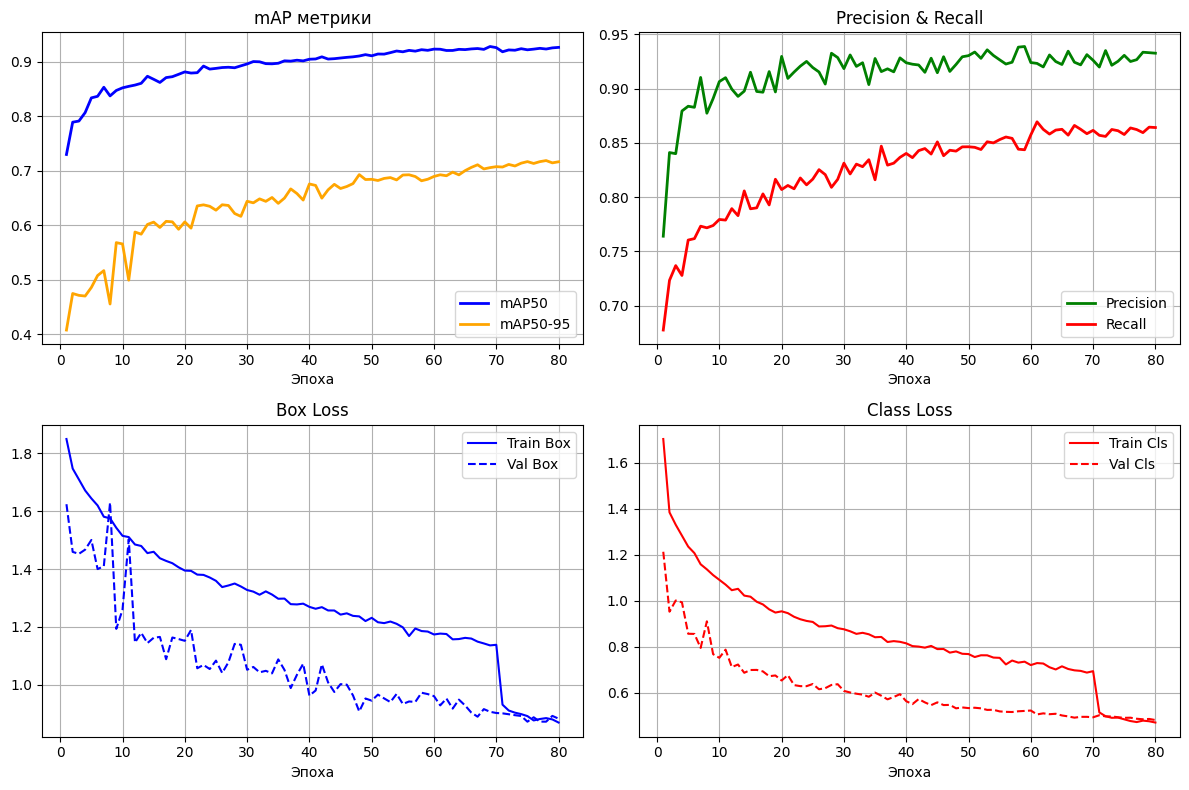

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# График mAP
axes[0,0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='blue', linewidth=2)
axes[0,0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='orange', linewidth=2)
axes[0,0].set_title('mAP метрики')
axes[0,0].set_xlabel('Эпоха')
axes[0,0].legend()
axes[0,0].grid(True)

# Precision/Recall
axes[0,1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='green', linewidth=2)
axes[0,1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='red', linewidth=2)
axes[0,1].set_title('Precision & Recall')
axes[0,1].set_xlabel('Эпоха')
axes[0,1].legend()
axes[0,1].grid(True)

# Losses
axes[1,0].plot(df['epoch'], df['train/box_loss'], label='Train Box', color='blue')
axes[1,0].plot(df['epoch'], df['val/box_loss'], label='Val Box', color='blue', linestyle='--')
axes[1,0].set_title('Box Loss')
axes[1,0].set_xlabel('Эпоха')
axes[1,0].legend()
axes[1,0].grid(True)

axes[1,1].plot(df['epoch'], df['train/cls_loss'], label='Train Cls', color='red')
axes[1,1].plot(df['epoch'], df['val/cls_loss'], label='Val Cls', color='red', linestyle='--')
axes[1,1].set_title('Class Loss')
axes[1,1].set_xlabel('Эпоха')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
import os

# Текущая папка
current_dir = os.getcwd()
print("="*60)
print(f"📁 ТЕКУЩАЯ ПАПКА: {current_dir}")
print("="*60)

# Смотрим содержимое
print("\n📂 СОДЕРЖИМОЕ ТЕКУЩЕЙ ПАПКИ:")
for item in os.listdir(current_dir):
    item_path = os.path.join(current_dir, item)
    if os.path.isdir(item_path):
        print(f"  📁 {item}/")
    else:
        size = os.path.getsize(item_path) / (1024*1024)  # в МБ
        print(f"  📄 {item} ({size:.2f} МБ)")

# Ищем все папки рекурсивно
print("\n🔍 ПОИСК ВСЕХ ПАПОК (рекурсивно):")
for root, dirs, files in os.walk(current_dir):
    level = root.replace(current_dir, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    
    # Показываем первые 3 файла в каждой папке
    for i, file in enumerate(files[:3]):
        if file.endswith('.jpg') or file.endswith('.png') or file.endswith('.txt'):
            print(f"{indent}    📄 {file}")
    if len(files) > 3:
        print(f"{indent}    ... и еще {len(files)-3} файлов")

# Проверяем критически важные файлы
print("\n" + "="*60)
print("🔎 ПРОВЕРКА ВАЖНЫХ ФАЙЛОВ:")
print("="*60)

important_files = ['best.pt', 'results.csv', 'sample_sub.csv']
for file in important_files:
    found = False
    for root, dirs, files in os.walk(current_dir):
        if file in files:
            full_path = os.path.join(root, file)
            size = os.path.getsize(full_path) / (1024*1024)
            print(f"✅ {file}: {full_path} ({size:.2f} МБ)")
            found = True
            break
    if not found:
        print(f"❌ {file}: НЕ НАЙДЕН!")

# Ищем папки с изображениями
print("\n🖼️  ПОИСК ПАПОК С ИЗОБРАЖЕНИЯМИ:")
for root, dirs, files in os.walk(current_dir):
    jpgs = [f for f in files if f.endswith('.jpg')]
    pngs = [f for f in files if f.endswith('.png')]
    if jpgs or pngs:
        print(f"📁 {root}")
        print(f"   📸 Найдено: {len(jpgs)} .jpg, {len(pngs)} .png")

# Ищем папки с YOLO dataset
print("\n🥷 ПОИСК YOLO DATASET (папки train/test):")
for root, dirs, files in os.walk(current_dir):
    if 'train' in dirs and 'test' in dirs:
        print(f"✅ НАЙДЕН YOLO DATASET: {root}")
        print(f"   train/ содержит: {len(os.listdir(os.path.join(root, 'train')))} элементов")
        print(f"   test/ содержит: {len(os.listdir(os.path.join(root, 'test')))} элементов")
    elif 'images' in dirs and 'labels' in dirs:
        print(f"✅ НАЙДЕНА ПАПКА С РАЗМЕТКОЙ: {root}")

📁 ТЕКУЩАЯ ПАПКА: /Users/tima/глубокое обучение /лаба2

📂 СОДЕРЖИМОЕ ТЕКУЩЕЙ ПАПКИ:
  📄 my_submission.csv (0.12 МБ)
  📄 Untitled.ipynb (0.16 МБ)
  📄 best.pt (49.60 МБ)
  📄 sample_sub.csv (0.12 МБ)
  📁 yolo_dataset/
  📄 data.yaml (0.00 МБ)
  📁 .ipynb_checkpoints/
  📄 test_images.rar (1524.96 МБ)
  📄 results.csv (0.01 МБ)

🔍 ПОИСК ВСЕХ ПАПОК (рекурсивно):
📁 лаба2/
    ... и еще 4 файлов
    📁 yolo_dataset/
        📁 train/
            📁 images/
                📄 0209-2_00874100.jpg
                📄 0209-34_01036900.jpg
                📄 0209-24_00872400.jpg
                ... и еще 3905 файлов
            📁 labels/
                📄 0209-13_00981100.txt
                📄 0209-34_01109600.txt
                📄 0209-25_01165300.txt
                ... и еще 3905 файлов
            📁 .ipynb_checkpoints/
        📁 .ipynb_checkpoints/
    📁 .ipynb_checkpoints/

🔎 ПРОВЕРКА ВАЖНЫХ ФАЙЛОВ:
✅ best.pt: /Users/tima/глубокое обучение /лаба2/best.pt (49.60 МБ)
✅ results.csv: /Users/tima/глубокое обу

In [8]:
import os
import pandas as pd
import json
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm
import cv2
import time
from multiprocessing import Pool, cpu_count
from functools import partial

print("🚀 SUBMISSION ДЛЯ MAC (ОПТИМИЗИРОВАНО)")
print("="*60)

# ============================================
# 1. КОНФИГУРАЦИЯ ДЛЯ MAC
# ============================================
class Config:
    test_path = "test_images"
    model_path = "best.pt"
    sample_sub_path = "sample_sub.csv"
    output_file = "submission_final.csv"
    
    # 🍎 ОПТИМИЗИРОВАНО ДЛЯ MAC
    CONF_THRESHOLD = 0.015
    CLASS_ID = 1
    
    # ВЫКЛЮЧАЕМ ВСЕ ТЯЖЕЛЫЕ ОПЦИИ
    USE_TTA = False
    USE_MULTI_SCALE = False
    
    # РАЗМЕР ИЗОБРАЖЕНИЯ (можно уменьшить для скорости)
    IMGSZ = 640  # вместо 896
    
    # ПАРАЛЛЕЛЬНАЯ ОБРАБОТКА
    NUM_WORKERS = max(1, cpu_count() - 1)  # Оставляем 1 ядро для системы
    BATCH_SIZE = 16  # Уменьшаем batch для Mac
    
    # Минимальный размер бокса
    MIN_BOX_SIZE = 0.01

config = Config()
print(f"🍏 Используем {config.NUM_WORKERS} ядер CPU")

# ============================================
# 2. ПРОВЕРКА ПУТЕЙ
# ============================================
print(f"📁 Тестовые изображения: {config.test_path}")
test_images = os.listdir(config.test_path)
print(f"📸 Найдено файлов: {len(test_images)}")

# ============================================
# 3. ЗАГРУЗКА МОДЕЛИ
# ============================================
model = YOLO(config.model_path)
print(f"✅ Модель загружена: {config.model_path}")

# ============================================
# 4. ЗАГРУЗКА SAMPLE SUBMISSION
# ============================================
sample_sub = pd.read_csv(config.sample_sub_path)
print(f"📄 sample_sub.csv загружен, {len(sample_sub)} изображений")

# ============================================
# 5. БЫСТРАЯ ФУНКЦИЯ ДЛЯ MAC
# ============================================
def predict_fast(img_path, config):
    """Максимально быстрая функция для Mac"""
    try:
        img = cv2.imread(img_path)
        if img is None:
            return []
        
        h, w, _ = img.shape
        
        # Используем прямой predict без лишних опций
        results = model.predict(
            img, 
            conf=config.CONF_THRESHOLD,
            imgsz=config.IMGSZ,  # Фиксированный размер
            classes=[config.CLASS_ID], 
            verbose=False,
            device='cpu'  # Явно указываем CPU
        )[0]
        
        if results.boxes is None or len(results.boxes) == 0:
            return []
        
        boxes = []
        boxes_data = results.boxes.xyxy.cpu().numpy()
        scores_data = results.boxes.conf.cpu().numpy()
        
        for box, score in zip(boxes_data, scores_data):
            x1, y1, x2, y2 = box
            
            # Проверяем минимальный размер
            width = (x2 - x1) / w
            height = (y2 - y1) / h
            if width * height < config.MIN_BOX_SIZE * config.MIN_BOX_SIZE:
                continue
            
            boxes.append([
                float(((x1 + x2) / 2) / w),
                float(((y1 + y2) / 2) / h),
                float(width),
                float(height),
                float(score)
            ])
        
        return boxes
        
    except Exception as e:
        print(f"⚠️ Ошибка в {img_path}: {e}")
        return []

# ============================================
# 6. ПАКЕТНАЯ ОБРАБОТКА
# ============================================
def process_batch(image_names, config):
    """Обработка батча изображений"""
    results = {}
    for img_name in tqdm(image_names, desc="Batch", leave=False):
        img_path = os.path.join(config.test_path, img_name)
        boxes = predict_fast(img_path, config)
        results[img_name] = boxes
    return results

# ============================================
# 7. ОСНОВНОЙ ЦИКЛ
# ============================================
print("\n🔮 НАЧАЛО ПРЕДСКАЗАНИЯ...")
print(f"⏱️ Ожидаемое время: ~{len(sample_sub) * 0.3 / 60:.1f} минут")
print("   (примерно 0.3 сек на изображение)\n")

start_time = time.time()
predictions = []
images_with_staff = 0
total_staff = 0

# Разбиваем на батчи для прогресс-бара
batch_size = 100
image_names = sample_sub['image_name'].tolist()

for i in range(0, len(image_names), batch_size):
    batch = image_names[i:i+batch_size]
    print(f"\n📦 Батч {i//batch_size + 1}/{(len(image_names)-1)//batch_size + 1}")
    
    for img_name in tqdm(batch, desc="  Прогресс"):
        img_path = os.path.join(config.test_path, img_name)
        boxes = predict_fast(img_path, config)
        
        if boxes:
            images_with_staff += 1
            total_staff += len(boxes)
            predictions.append(json.dumps(boxes, separators=(',', ':')))
        else:
            predictions.append("[]")

elapsed_time = time.time() - start_time
print(f"\n✅ Предсказание завершено за {elapsed_time/60:.2f} минут")
print(f"⏱️ Среднее время: {elapsed_time/len(sample_sub):.2f} сек на изображение")

# ============================================
# 8. СОЗДАЕМ SUBMISSION
# ============================================
submission = pd.DataFrame({
    'id': sample_sub['id'],
    'image_name': sample_sub['image_name'],
    'boxes': predictions
})

# ============================================
# 9. СОХРАНЯЕМ
# ============================================
submission.to_csv(config.output_file, index=False)

print(f"\n✅ SUBMISSION ГОТОВ: {config.output_file}")
print("="*50)
print("📊 СТАТИСТИКА:")
print(f"   - Всего изображений: {len(submission)}")
print(f"   - Изображений со staff: {images_with_staff}")
print(f"   - Без staff: {len(submission) - images_with_staff}")
print(f"   - Всего staff детекций: {total_staff}")
print(f"   - Среднее staff на изображение: {total_staff/len(submission):.2f}")

# ============================================
# 10. ПРОВЕРКА ПЕРВЫХ ПРЕДСКАЗАНИЙ
# ============================================
print("\n👀 ПРИМЕРЫ ПРЕДСКАЗАНИЙ:")
for i in range(min(5, len(submission))):
    boxes = json.loads(predictions[i])
    print(f"   {submission.iloc[i]['image_name']}: {len(boxes)} staff")
    if boxes:
        print(f"      Уверенность: {[f'{b[4]:.3f}' for b in boxes[:3]]}")

print("\n" + "="*50)
print("🎉 ГОТОВО! Файл можно отправлять на Kaggle")

🚀 SUBMISSION ДЛЯ MAC (ОПТИМИЗИРОВАНО)
🍏 Используем 9 ядер CPU
📁 Тестовые изображения: test_images
📸 Найдено файлов: 4455
✅ Модель загружена: best.pt
📄 sample_sub.csv загружен, 4454 изображений

🔮 НАЧАЛО ПРЕДСКАЗАНИЯ...
⏱️ Ожидаемое время: ~22.3 минут
   (примерно 0.3 сек на изображение)


📦 Батч 1/45


  Прогресс: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 12.83it/s]



📦 Батч 2/45


  Прогресс: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.16it/s]



📦 Батч 3/45


...


📦 Батч 44/45


  Прогресс: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.07it/s]



📦 Батч 45/45


  Прогресс: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 54/54 [00:04<00:00, 13.15it/s]


✅ Предсказание завершено за 5.72 минут
⏱️ Среднее время: 0.08 сек на изображение

✅ SUBMISSION ГОТОВ: submission_final.csv
📊 СТАТИСТИКА:
   - Всего изображений: 4454
   - Изображений со staff: 2078
   - Без staff: 2376
   - Всего staff детекций: 4191
   - Среднее staff на изображение: 0.94

👀 ПРИМЕРЫ ПРЕДСКАЗАНИЙ:
   32_09-02-30-000.jpg: 0 staff
   14.1_00-03-32-500.jpg: 0 staff
   19.1_00-02-05-000.jpg: 1 staff
      Уверенность: ['0.744']
   14_09-02-42-500.jpg: 1 staff
      Уверенность: ['0.016']
   3_01-02-30-000.jpg: 4 staff
      Уверенность: ['0.496', '0.216', '0.104']

🎉 ГОТОВО! Файл можно отправлять на Kaggle
